# 04 — Modeling
Train 7 XGBoost models (one per target) on 2015–2021 Masters data and evaluate on 2022 holdout.

In [1]:
# Fix for macOS: XGBoost needs libomp; sklearn ships one we can reuse
import os, sys
sklearn_dylibs = os.path.join(
    os.path.dirname(sys.executable).replace('/bin', ''),
    'lib', f'python{sys.version_info.major}.{sys.version_info.minor}',
    'site-packages', 'sklearn', '.dylibs'
)
existing = os.environ.get('DYLD_LIBRARY_PATH', '')
os.environ['DYLD_LIBRARY_PATH'] = (sklearn_dylibs + ':' + existing).strip(':')

import ctypes, glob
for lib in glob.glob(os.path.join(sklearn_dylibs, 'libomp*.dylib')):
    try:
        ctypes.CDLL(lib)
    except Exception:
        pass

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib
import xgboost as xgb
from pathlib import Path
from sklearn.metrics import roc_auc_score, log_loss, mean_absolute_error, mean_squared_error

FIGURES = Path('../outputs/figures')
CSV_OUT = Path('../outputs/csv')
MODELS  = Path('../outputs/models')
for d in [FIGURES, CSV_OUT, MODELS]:
    d.mkdir(parents=True, exist_ok=True)

FEATURE_COLS = [
    # 12-event exponential-decay rolling averages
    'sg_total_weighted', 'sg_app_weighted', 'sg_putt_weighted',
    'sg_arg_weighted',   'sg_ott_weighted',  'sg_t2g_weighted',
    'top10_rate', 'cut_rate', 'augusta_fit',
    # Augusta history
    'masters_appearances', 'masters_avg_finish', 'masters_best_finish',
    'masters_wins', 'recent_form_bonus',
    # Last-6-events simple averages
    'l6_sg_total_avg', 'l6_sg_app_avg', 'l6_sg_putt_avg',
    'l6_top10_rate', 'l6_cut_rate', 'l6_avg_finish',
]

CLF_TARGETS = ['won', 'top5', 'top10', 'top16', 'top32', 'made_cut']
REG_TARGET  = 'finish_position'

print(f'XGBoost version: {xgb.__version__}')
print(f'Total features:  {len(FEATURE_COLS)}')

XGBoost version: 3.0.2
Total features:  20


## 1. Load & clean feature matrix

In [3]:
fm = pd.read_csv('../data/features/feature_matrix.csv')
print(f'Loaded: {fm.shape}')

# Impute masters_avg_finish and masters_best_finish with season-field mean
for col in ['masters_avg_finish', 'masters_best_finish']:
    field_mean  = fm.groupby('season')[col].transform('mean')
    global_mean = fm[col].mean()
    fill = field_mean.fillna(global_mean)
    null_before = fm[col].isna().sum()
    fm[col] = fm[col].fillna(fill)
    print(f'  {col}: imputed {null_before} NaNs with season-field mean')

# Safety-net imputation for l6 features (nb03 already handles these,
# but guard against any residual NaNs with column mean)
l6_cols = ['l6_sg_total_avg', 'l6_sg_app_avg', 'l6_sg_putt_avg',
           'l6_top10_rate', 'l6_cut_rate', 'l6_avg_finish']
for col in l6_cols:
    if col in fm.columns:
        n = fm[col].isna().sum()
        if n > 0:
            fm[col] = fm[col].fillna(fm[col].mean())
            print(f'  {col}: imputed {n} NaNs with column mean')

# Drop any remaining NaN rows in feature columns
pre = len(fm)
fm = fm.dropna(subset=FEATURE_COLS)
if len(fm) < pre:
    print(f'  Dropped {pre - len(fm)} rows still containing NaN after imputation')

print(f'Final shape after cleaning: {fm.shape}')
fm.head(2)

Loaded: (621, 31)
  masters_avg_finish: imputed 197 NaNs with season-field mean
  masters_best_finish: imputed 197 NaNs with season-field mean
  l6_sg_total_avg: imputed 8 NaNs with column mean
  l6_sg_app_avg: imputed 8 NaNs with column mean
  l6_sg_putt_avg: imputed 8 NaNs with column mean
Final shape after cleaning: (621, 31)


,player,season,masters_date,n_prior_events,sg_total_weighted,sg_app_weighted,sg_putt_weighted,sg_arg_weighted,sg_ott_weighted,sg_t2g_weighted,...,l6_top10_rate,l6_cut_rate,l6_avg_finish,finish_position,made_cut,top32,top16,top10,top5,won
0,abraham ancer,2022,2022-04-10,12,-0.096299,-0.055377,-0.027298,-0.378202,0.277099,-0.157740,...,0.000000,0.666667,52.500000,85.0,0,0,0,0,0,0
1,adam scott,2022,2022-04-10,12,0.678402,0.481911,0.529326,-0.296182,-0.067498,0.117969,...,0.166667,0.833333,39.833333,48.0,1,0,0,0,0,0


## 2. Train / validation split — train 2015–2021, validate 2022

In [4]:
train = fm[fm['season'] <= 2021].copy()
val   = fm[fm['season'] == 2022].copy()

X_train = train[FEATURE_COLS]
X_val   = val[FEATURE_COLS]

print(f'Train: {len(train)} rows ({train["season"].nunique()} seasons: {sorted(train["season"].unique())})')
print(f'Val:   {len(val)} rows (season 2022)')
print()
print('Train target distributions:')
for t in CLF_TARGETS:
    n = train[t].sum()
    pct = 100 * n / len(train)
    print(f'  {t:15s}: {n:3d} positives ({pct:.1f}%)')

Train: 540 rows (7 seasons: [np.int64(2015), np.int64(2016), np.int64(2017), np.int64(2018), np.int64(2019), np.int64(2020), np.int64(2021)])
Val:   81 rows (season 2022)

Train target distributions:
  won            :   7 positives (1.3%)
  top5           :  44 positives (8.1%)
  top10          :  79 positives (14.6%)
  top16          : 113 positives (20.9%)
  top32          : 226 positives (41.9%)
  made_cut       : 374 positives (69.3%)


## 3. Train 6 classifiers + 1 regressor

In [5]:
XGB_CLF_PARAMS = dict(
    n_estimators=400,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.1,
    reg_lambda=1.0,
    eval_metric='logloss',
    random_state=42,
    verbosity=0
)

XGB_REG_PARAMS = dict(
    n_estimators=400,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.1,
    reg_lambda=1.0,
    eval_metric='rmse',
    random_state=42,
    verbosity=0
)

models = {}

# Classifiers with class-imbalance correction
for target in CLF_TARGETS:
    y_train = train[target]
    n_pos = y_train.sum()
    n_neg = len(y_train) - n_pos
    spw = round(n_neg / n_pos, 2) if n_pos > 0 else 1.0

    clf = xgb.XGBClassifier(scale_pos_weight=spw, **XGB_CLF_PARAMS)
    clf.fit(X_train, y_train)
    models[target] = clf
    print(f'Trained classifier: {target:15s}  scale_pos_weight={spw}')

# Regressor
reg = xgb.XGBRegressor(**XGB_REG_PARAMS)
reg.fit(X_train, train[REG_TARGET])
models[REG_TARGET] = reg
print(f'Trained regressor:  {REG_TARGET}')

Trained classifier: won              scale_pos_weight=76.14


Trained classifier: top5             scale_pos_weight=11.27


Trained classifier: top10            scale_pos_weight=5.84


Trained classifier: top16            scale_pos_weight=3.78


Trained classifier: top32            scale_pos_weight=1.39


Trained classifier: made_cut         scale_pos_weight=0.44


Trained regressor:  finish_position


## 4. Evaluate on 2022 holdout

In [6]:
eval_rows = []

print(f'{"Target":<18} {"Type":<12} {"ROC-AUC":>8} {"LogLoss":>9} {"MAE":>8} {"RMSE":>8}')
print('-' * 70)

for target in CLF_TARGETS:
    y_true = val[target]
    y_prob = models[target].predict_proba(X_val)[:, 1]

    auc  = roc_auc_score(y_true, y_prob)
    ll   = log_loss(y_true, y_prob)
    print(f'{target:<18} {"Classifier":<12} {auc:>8.4f} {ll:>9.4f} {"-":>8} {"-":>8}')
    eval_rows.append({'target': target, 'type': 'classifier',
                      'roc_auc': round(auc, 4), 'log_loss': round(ll, 4),
                      'mae': None, 'rmse': None})

y_true_reg = val[REG_TARGET]
y_pred_reg = models[REG_TARGET].predict(X_val)
mae  = mean_absolute_error(y_true_reg, y_pred_reg)
rmse = np.sqrt(mean_squared_error(y_true_reg, y_pred_reg))
print(f'{REG_TARGET:<18} {"Regressor":<12} {"-":>8} {"-":>9} {mae:>8.2f} {rmse:>8.2f}')
eval_rows.append({'target': REG_TARGET, 'type': 'regressor',
                  'roc_auc': None, 'log_loss': None,
                  'mae': round(mae, 2), 'rmse': round(rmse, 2)})

eval_df = pd.DataFrame(eval_rows)
eval_df.to_csv(CSV_OUT / 'model_evaluation.csv', index=False)
print('\nSaved: outputs/csv/model_evaluation.csv')

Target             Type          ROC-AUC   LogLoss      MAE     RMSE
----------------------------------------------------------------------
won                Classifier     0.9625    0.0463        -        -
top5               Classifier     0.9158    0.1783        -        -
top10              Classifier     0.7221    0.4630        -        -
top16              Classifier     0.6202    0.7230        -        -
top32              Classifier     0.5638    0.8653        -        -
made_cut           Classifier     0.7440    0.5798        -        -
finish_position    Regressor           -         -    24.28    29.01

Saved: outputs/csv/model_evaluation.csv


## 5. Feature importance (won model)

Feature importances (won model):
            feature  importance
    sg_t2g_weighted    0.253571
    sg_arg_weighted    0.115751
      l6_avg_finish    0.070411
      l6_top10_rate    0.064410
    sg_app_weighted    0.048707
    l6_sg_total_avg    0.044230
masters_appearances    0.043840
         top10_rate    0.043470
      l6_sg_app_avg    0.041860
  sg_total_weighted    0.040664
 masters_avg_finish    0.038180
        l6_cut_rate    0.036301
           cut_rate    0.033989
    sg_ott_weighted    0.031300
masters_best_finish    0.030550
        augusta_fit    0.028933
   sg_putt_weighted    0.021392
     l6_sg_putt_avg    0.012443
       masters_wins    0.000000
  recent_form_bonus    0.000000


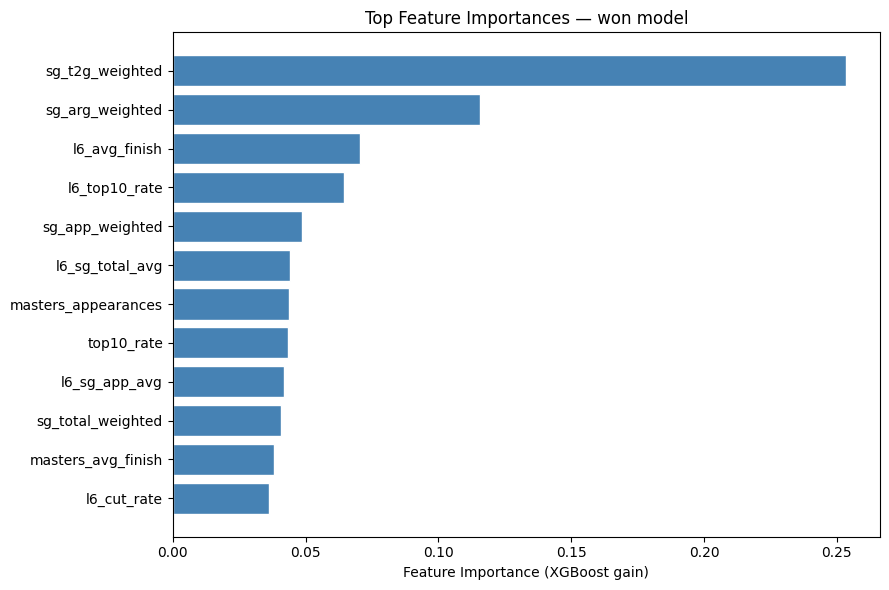

Saved: outputs/figures/feature_importance.png


In [7]:
importances = models['won'].feature_importances_
fi_df = pd.DataFrame({'feature': FEATURE_COLS, 'importance': importances})
fi_df = fi_df.sort_values('importance', ascending=False)

fi_df.to_csv(CSV_OUT / 'feature_importance.csv', index=False)
print('Feature importances (won model):')
print(fi_df.to_string(index=False))

fig, ax = plt.subplots(figsize=(9, 6))
top12 = fi_df.head(12).sort_values('importance')
ax.barh(top12['feature'], top12['importance'], color='steelblue', edgecolor='white')
ax.set_xlabel('Feature Importance (XGBoost gain)')
ax.set_title('Top Feature Importances — won model')
plt.tight_layout()
plt.savefig(FIGURES / 'feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: outputs/figures/feature_importance.png')

## 6. Save all models

In [8]:
for name, model in models.items():
    path = MODELS / f'xgb_{name.replace("_","-")}.joblib'
    joblib.dump(model, path)
    print(f'Saved: {path}')

Saved: ../outputs/models/xgb_won.joblib


Saved: ../outputs/models/xgb_top5.joblib
Saved: ../outputs/models/xgb_top10.joblib


Saved: ../outputs/models/xgb_top16.joblib
Saved: ../outputs/models/xgb_top32.joblib
Saved: ../outputs/models/xgb_made-cut.joblib
Saved: ../outputs/models/xgb_finish-position.joblib


## 7. 2022 validation — top predicted players vs actual results

In [9]:
val_out = val[['player', 'finish_position', 'made_cut', 'top10', 'won']].copy()
val_out['p_won']    = models['won'].predict_proba(X_val)[:, 1]
val_out['p_top10']  = models['top10'].predict_proba(X_val)[:, 1]
val_out['pred_finish'] = models['finish_position'].predict(X_val)

val_out = val_out.sort_values('p_won', ascending=False)

print('2022 holdout — top 15 by predicted win probability:')
print(val_out.head(15)[['player','p_won','p_top10','pred_finish','finish_position']]
      .to_string(index=False))

# Actual 2022 winner
winner_2022 = val_out[val_out['won'] == 1]
print(f'\nActual 2022 winner: {winner_2022["player"].values[0]} '
      f'(model rank: #{val_out.index.get_loc(winner_2022.index[0]) + 1} '
      f'of {len(val_out)} by p_won)')

2022 holdout — top 15 by predicted win probability:
             player    p_won  p_top10  pred_finish  finish_position
     russell henley 0.095309 0.137678    41.990597             30.0
    joaquin niemann 0.060474 0.199066    20.284119             35.0
matthew fitzpatrick 0.058405 0.023508    53.301640             14.0
  scottie scheffler 0.037643 0.074304    25.576736              1.0
      daniel berger 0.030982 0.129433    32.092037             50.0
    tommy fleetwood 0.020383 0.006881    21.491587             14.0
      justin thomas 0.017259 0.315210    27.315052              8.0
      danny willett 0.016812 0.009950    48.135647             12.0
         sungjae im 0.012452 0.389586    23.049335              8.0
    collin morikawa 0.009606 0.127180    52.229691              5.0
      cameron smith 0.009170 0.113873    31.152531              3.0
      sergio garcia 0.008382 0.291014    40.309761             23.0
      corey conners 0.007547 0.072785    51.395748              

## 8. Leave-one-year-out cross-validation
Trains temporary models on 6 of 7 years, tests on the held-out year — repeated for every year.
Gives a more robust accuracy estimate than a single 2022 holdout.
Note: the final saved models (Section 6) are not affected — they stay trained on 2015–2021.

In [10]:
# ── Leave-one-year-out cross-validation ──────────────────────────────────────
# 2020 excluded: COVID-postponed November Masters had a non-standard field
# and calendar context — included in final training but excluded from CV folds
# to avoid contaminating year-to-year comparisons.
CV_YEARS = [2015, 2016, 2017, 2018, 2019, 2021, 2022]

cv_records = []   # one row per (year, target)

for held_out in CV_YEARS:
    cv_train = fm[fm['season'] != held_out].copy()
    cv_val   = fm[fm['season'] == held_out].copy()

    if len(cv_val) == 0:
        continue

    X_cv_train = cv_train[FEATURE_COLS]
    X_cv_val   = cv_val[FEATURE_COLS]

    fold_models = {}

    # Train classifiers
    for target in CLF_TARGETS:
        y_tr = cv_train[target]
        n_pos = y_tr.sum()
        n_neg = len(y_tr) - n_pos
        spw = round(n_neg / n_pos, 2) if n_pos > 0 else 1.0
        clf = xgb.XGBClassifier(scale_pos_weight=spw, **XGB_CLF_PARAMS)
        clf.fit(X_cv_train, y_tr)
        fold_models[target] = clf

    # Train regressor
    reg = xgb.XGBRegressor(**XGB_REG_PARAMS)
    reg.fit(X_cv_train, cv_train[REG_TARGET])
    fold_models[REG_TARGET] = reg

    # Evaluate classifiers
    for target in CLF_TARGETS:
        y_true = cv_val[target]
        y_prob = fold_models[target].predict_proba(X_cv_val)[:, 1]
        n_pos_val = y_true.sum()
        if n_pos_val == 0 or n_pos_val == len(y_true):
            auc = np.nan  # degenerate fold — no positive/negative examples
            ll  = np.nan
        else:
            auc = roc_auc_score(y_true, y_prob)
            ll  = log_loss(y_true, y_prob)
        cv_records.append({
            'held_out_year': held_out,
            'target': target,
            'type': 'classifier',
            'roc_auc': round(auc, 4) if not np.isnan(auc) else np.nan,
            'log_loss': round(ll, 4) if not np.isnan(ll) else np.nan,
            'mae': np.nan,
            'rmse': np.nan,
            'n_val': len(cv_val),
        })

    # Evaluate regressor
    y_true_r = cv_val[REG_TARGET]
    y_pred_r = fold_models[REG_TARGET].predict(X_cv_val)
    mae_r  = mean_absolute_error(y_true_r, y_pred_r)
    rmse_r = np.sqrt(mean_squared_error(y_true_r, y_pred_r))
    cv_records.append({
        'held_out_year': held_out,
        'target': REG_TARGET,
        'type': 'regressor',
        'roc_auc': np.nan,
        'log_loss': np.nan,
        'mae': round(mae_r, 2),
        'rmse': round(rmse_r, 2),
        'n_val': len(cv_val),
    })

    print(f'Year {held_out} (n={len(cv_val):2d}) | '
          + '  '.join(
              f"{t}={cv_records[-(len(CLF_TARGETS)+1) + i]['roc_auc']:.3f}"
              for i, t in enumerate(['won','top5','top10','top16','top32','made_cut'])
          )
          + f"  MAE={mae_r:.1f}")

cv_df = pd.DataFrame(cv_records)
print(f'\nTotal CV records: {len(cv_df)}')

Year 2015 (n=72) | won=0.944  top5=0.785  top10=0.744  top16=0.670  top32=0.658  made_cut=0.668  MAE=22.6


Year 2016 (n=73) | won=0.819  top5=0.674  top10=0.749  top16=0.702  top32=0.622  made_cut=0.638  MAE=22.9


Year 2017 (n=76) | won=0.027  top5=0.673  top10=0.689  top16=0.743  top32=0.626  made_cut=0.529  MAE=26.0


Year 2018 (n=72) | won=0.070  top5=0.734  top10=0.839  top16=0.778  top32=0.651  made_cut=0.641  MAE=23.0


Year 2019 (n=78) | won=0.961  top5=0.721  top10=0.719  top16=0.769  top32=0.776  made_cut=0.722  MAE=19.3


Year 2021 (n=82) | won=0.198  top5=0.770  top10=0.749  top16=0.648  top32=0.632  made_cut=0.632  MAE=25.1


Year 2022 (n=81) | won=0.963  top5=0.916  top10=0.722  top16=0.620  top32=0.564  made_cut=0.744  MAE=24.3

Total CV records: 49


In [11]:
# ── CV summary table ─────────────────────────────────────────────────────────
# Single-holdout (2022) AUCs from Section 4 for comparison
single_holdout = {
    'won': 0.9625, 'top5': 0.9158, 'top10': 0.7221,
    'top16': 0.6202, 'top32': 0.5638, 'made_cut': 0.7440,
    'finish_position_mae': 24.28, 'finish_position_rmse': 29.01,
}

clf_cv = cv_df[cv_df['type'] == 'classifier'].copy()
reg_cv = cv_df[cv_df['type'] == 'regressor'].copy()

print(f'{"Target":<18} {"Mean AUC":>9} {"Std AUC":>8} {"Min AUC":>8} {"Max AUC":>8}  {"2022-only":>9}  {"Δ vs 2022":>9}')
print('-' * 80)

cv_summary = {}
for target in CLF_TARGETS:
    aucs = clf_cv[clf_cv['target'] == target]['roc_auc'].dropna()
    mean_auc = aucs.mean()
    std_auc  = aucs.std()
    min_auc  = aucs.min()
    max_auc  = aucs.max()
    s22      = single_holdout[target]
    delta    = mean_auc - s22
    cv_summary[target] = {'mean': mean_auc, 'std': std_auc, 'min': min_auc, 'max': max_auc}
    print(f'{target:<18} {mean_auc:>9.4f} {std_auc:>8.4f} {min_auc:>8.4f} {max_auc:>8.4f}  {s22:>9.4f}  {delta:>+9.4f}')

# Regressor
mae_vals  = reg_cv['mae'].dropna()
rmse_vals = reg_cv['rmse'].dropna()
print(f'{"finish_pos MAE":<18} {mae_vals.mean():>9.2f} {mae_vals.std():>8.2f} {mae_vals.min():>8.2f} {mae_vals.max():>8.2f}  {single_holdout["finish_position_mae"]:>9.2f}  {mae_vals.mean()-single_holdout["finish_position_mae"]:>+9.2f}')
print(f'{"finish_pos RMSE":<18} {rmse_vals.mean():>9.2f} {rmse_vals.std():>8.2f} {rmse_vals.min():>8.2f} {rmse_vals.max():>8.2f}  {single_holdout["finish_position_rmse"]:>9.2f}  {rmse_vals.mean()-single_holdout["finish_position_rmse"]:>+9.2f}')

# ── Hardest and easiest years ─────────────────────────────────────────────────
# Score each year by average AUC across all 6 classifiers
print('\n── Per-year average AUC (all 6 classifiers) ──')
year_avgs = (
    clf_cv.groupby('held_out_year')['roc_auc']
    .mean()
    .sort_values()
)
for yr, avg in year_avgs.items():
    print(f'  {yr}: {avg:.4f}')

hardest = year_avgs.idxmin()
easiest = year_avgs.idxmax()
print(f'\nHardest year to predict: {hardest} (avg AUC={year_avgs[hardest]:.4f})')
print(f'Easiest year to predict: {easiest} (avg AUC={year_avgs[easiest]:.4f})')

# ── Save ──────────────────────────────────────────────────────────────────────
cv_out_path = CSV_OUT / 'cross_validation_results.csv'
cv_df.to_csv(cv_out_path, index=False)
print(f'\nSaved: {cv_out_path}')

Target              Mean AUC  Std AUC  Min AUC  Max AUC  2022-only  Δ vs 2022
--------------------------------------------------------------------------------
won                   0.5687   0.4458   0.0267   0.9625     0.9625    -0.3938
top5                  0.7534   0.0834   0.6732   0.9158     0.9158    -0.1624
top10                 0.7444   0.0468   0.6894   0.8390     0.7221    +0.0223
top16                 0.7043   0.0613   0.6202   0.7779     0.6202    +0.0841
top32                 0.6471   0.0646   0.5638   0.7761     0.5638    +0.0833
made_cut              0.6535   0.0700   0.5290   0.7440     0.7440    -0.0905
finish_pos MAE         23.30     2.17    19.27    25.98      24.28      -0.98
finish_pos RMSE        28.31     2.44    23.91    31.47      29.01      -0.70

── Per-year average AUC (all 6 classifiers) ──
  2017: 0.5479
  2021: 0.6048
  2018: 0.6190
  2016: 0.7007
  2015: 0.7448
  2022: 0.7547
  2019: 0.7781

Hardest year to predict: 2017 (avg AUC=0.5479)
Easiest year to 